# Modelos baseline para `target_risk_20d`

**TFM:** estimación de riesgo de mercado con Machine Learning.

Primera referencia de modelos antes de pasar a algoritmos más complejos (Random Forest, XGBoost, etc.).

- **Datos:** particiones en `data/processed/modeling/`
- **Target:** episodio de riesgo en los próximos 20 días (`target_risk_20d`)
- **Sin** tuning complejo, **sin** SHAP en esta fase


## 0. Librerías y rutas


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

MODELING_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_risk_20d"
FORBIDDEN_IN_X = [
    "date",
    "future_drawdown_20d",
    "future_vol_20d_ann",
    "target_drawdown_20d_5",
    "target_volatility_20d_20",
    "target_risk_20d",
]

RANDOM_STATE = 42


## 1. Cargar datos y crear matrices X / y


In [2]:
FEATURE_COLS = (
    MODELING_DIR / "feature_columns.txt"
).read_text(encoding="utf-8").strip().split("\n")

df_train = pd.read_csv(MODELING_DIR / "train.csv", parse_dates=["date"])
df_val = pd.read_csv(MODELING_DIR / "validation.csv", parse_dates=["date"])
df_test = pd.read_csv(MODELING_DIR / "test.csv", parse_dates=["date"])

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train[TARGET_COL].copy()
X_val = df_val[FEATURE_COLS].copy()
y_val = df_val[TARGET_COL].copy()
X_test = df_test[FEATURE_COLS].copy()
y_test = df_test[TARGET_COL].copy()

# --- Comprobaciones de seguridad ---
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns) == FEATURE_COLS
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    assert "date" not in X.columns
    for col in FORBIDDEN_IN_X:
        if col != "date" and col != TARGET_COL:
            assert col not in X.columns, f"{col} en X_{name}"
    assert X.isna().sum().sum() == 0

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    assert y.isna().sum() == 0
    assert set(y.unique()).issubset({0, 1}), f"y_{name} no es binario"

print("OK: datos cargados")
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)


OK: datos cargados
Train: (6302, 28) | Val: (986, 28) | Test: (1560, 28)


## 2. Resumen de clases por partición

El problema está **desbalanceado** (más días sin episodio de riesgo que con episodio).

Por eso la **accuracy** puede ser engañosa: un modelo que siempre predice "sin riesgo" tendría buena accuracy pero no detectaría crisis.

Métricas más útiles aquí: **recall** (capacidad de detectar riesgo), **precision** (fiabilidad cuando alerta) y **PR-AUC** (rendimiento con clases desbalanceadas).


In [3]:
def class_summary(df, split_name):
    n = len(df)
    n_pos = int((df[TARGET_COL] == 1).sum())
    n_neg = n - n_pos
    return {
        "split": split_name,
        "filas": n,
        "positivos": n_pos,
        "pct_positivos": round(n_pos / n * 100, 2),
        "negativos": n_neg,
        "pct_negativos": round(n_neg / n * 100, 2),
    }

class_summary_df = pd.DataFrame([
    class_summary(df_train, "train"),
    class_summary(df_val, "validation"),
    class_summary(df_test, "test"),
])
display(class_summary_df)


,split,filas,positivos,pct_positivos,negativos,pct_negativos
0,train,6302,1605,25.47,4697,74.53
1,validation,986,136,13.79,850,86.21
2,test,1560,449,28.78,1111,71.22


## 3. Función de evaluación

Métricas incluidas:

- **Accuracy:** aciertos totales / total (puede ser alta aunque falle en la clase minoritaria).
- **Precision:** de las alertas de riesgo, cuántas eran correctas (menos falsas alarmas → precision alta).
- **Recall:** de los días con riesgo real, cuántos detectamos (crisis no detectadas → recall bajo).
- **F1:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad de separar clases usando probabilidades (0.5 = azar, 1 = perfecto).
- **PR-AUC (average precision):** área bajo curva precision-recall; muy informativa con desbalanceo.


In [4]:
def evaluate_classifier(model_name, split_name, y_true, y_pred, y_proba=None):
    """Devuelve un diccionario con métricas de clasificación binaria."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "modelo": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
    }

    if y_proba is not None:
        y_proba = np.asarray(y_proba)
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
        out["pr_auc"] = average_precision_score(y_true, y_proba)

    return out


def make_result_row(modelo, split, y_true, y_pred, y_proba=None,
                    variant_features=np.nan, C=np.nan,
                    threshold_type=np.nan, threshold=np.nan):
    """Envuelve evaluate_classifier con metadatos extra para tablas unificadas."""
    row = evaluate_classifier(modelo, split, y_true, y_pred, y_proba)
    row["variant_features"] = variant_features
    row["C"] = C
    row["threshold_type"] = threshold_type
    row["threshold"] = threshold
    return row


THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)


def find_best_threshold_f1(y_true, y_proba, grid=THRESHOLD_GRID):
    """
    Elige threshold que maximiza F1 en validation.
    Empates: mayor precision, luego threshold más alto (menos alertas).
    """
    best_thr = grid[0]
    best_score = (-1.0, -1.0, -1.0)

    for thr in grid:
        pred = (y_proba >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        score = (f1, prec, thr)
        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr)


print("Funciones de evaluación y selección de threshold definidas.")


Funciones de evaluación y selección de threshold definidas.


## 4. Baseline 1: DummyClassifier (clase más frecuente)

Predice **siempre** la clase mayoritaria (normalmente "sin riesgo"). Referencia mínima.


In [5]:
dummy_mf = DummyClassifier(strategy="most_frequent")
dummy_mf.fit(X_train, y_train)

results_rows = []

for split_name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    pred = dummy_mf.predict(X)
    results_rows.append(
        make_result_row("Dummy most_frequent", split_name, y, pred,
                        threshold_type="n/a")
    )

display(pd.DataFrame(results_rows))


,modelo,split,accuracy,precision,recall,f1,tn,fp,fn,tp,roc_auc,pr_auc,variant_features,C,threshold_type,threshold
0,Dummy most_frequent,train,0.745319,0.0,0.0,0.0,4697,0,1605,0,NaN,NaN,NaN,NaN,n/a,NaN
1,Dummy most_frequent,validation,0.862069,0.0,0.0,0.0,850,0,136,0,NaN,NaN,NaN,NaN,n/a,NaN
2,Dummy most_frequent,test,0.712179,0.0,0.0,0.0,1111,0,449,0,NaN,NaN,NaN,NaN,n/a,NaN


## 5. Baseline 2: DummyClassifier (estratificado)

Predice al azar respetando **aproximadamente** la proporción de clases del train, sin aprender patrones.


In [6]:
dummy_strat = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy_strat.fit(X_train, y_train)

for split_name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    pred = dummy_strat.predict(X)
    results_rows.append(
        make_result_row("Dummy stratified", split_name, y, pred,
                        threshold_type="n/a")
    )

display(pd.DataFrame(results_rows[-3:]))


,modelo,split,accuracy,precision,recall,f1,tn,fp,fn,tp,roc_auc,pr_auc,variant_features,C,threshold_type,threshold
0,Dummy stratified,train,0.621231,0.253157,0.249844,0.251489,3514,1183,1204,401,NaN,NaN,NaN,NaN,n/a,NaN
1,Dummy stratified,validation,0.687627,0.150407,0.272059,0.193717,641,209,99,37,NaN,NaN,NaN,NaN,n/a,NaN
2,Dummy stratified,test,0.577564,0.238806,0.213808,0.225617,805,306,353,96,NaN,NaN,NaN,NaN,n/a,NaN


## 6. Baseline financiero: regla simple con VIX

Regla interpretable: **riesgo alto cuando el VIX supera un umbral**.

- Umbrales candidatos: percentiles 50–95 del VIX en **train** (30 valores).
- Elegimos el umbral que **maximiza F1 en validation** (no usamos test para calibrar).


Mejor umbral VIX (max F1 en validation): 17.77


,umbral_vix,precision_val,recall_val,f1_val
0,17.7700,0.312849,0.411765,0.355556
1,18.0400,0.315476,0.389706,0.348684
2,18.3500,0.314465,0.367647,0.338983
6,19.5600,0.372727,0.301471,0.333333
3,18.6300,0.315436,0.345588,0.329825
4,18.9560,0.325926,0.323529,0.324723
7,19.8700,0.371429,0.286765,0.323651
5,19.2800,0.338710,0.308824,0.323077
8,20.1900,0.340659,0.227941,0.273128
9,20.5147,0.357143,0.220588,0.272727


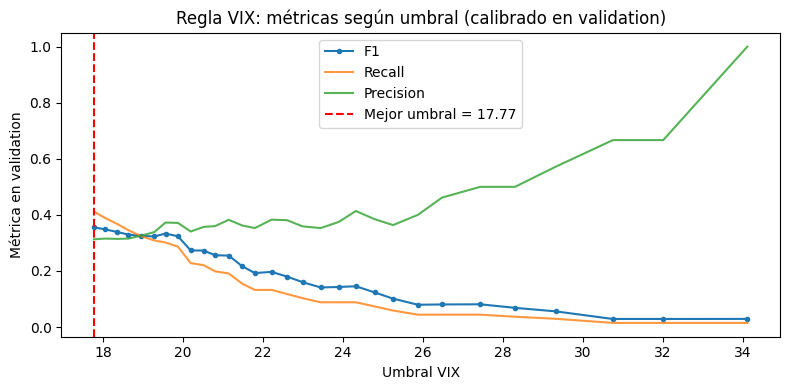

In [7]:
vix_train = X_train["vix"].values
vix_val = X_val["vix"].values
vix_test = X_test["vix"].values

percentiles = np.linspace(50, 95, 30)
candidate_thresholds = np.percentile(vix_train, percentiles)

vix_threshold_rows = []
for thr in candidate_thresholds:
    pred_val = (vix_val >= thr).astype(int)
    vix_threshold_rows.append({
        "umbral_vix": round(thr, 4),
        "precision_val": precision_score(y_val, pred_val, zero_division=0),
        "recall_val": recall_score(y_val, pred_val, zero_division=0),
        "f1_val": f1_score(y_val, pred_val, zero_division=0),
    })

vix_threshold_df = pd.DataFrame(vix_threshold_rows)
best_idx = vix_threshold_df["f1_val"].idxmax()
best_vix_threshold = float(vix_threshold_df.loc[best_idx, "umbral_vix"])

print("Mejor umbral VIX (max F1 en validation):", best_vix_threshold)
display(vix_threshold_df.sort_values("f1_val", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vix_threshold_df["umbral_vix"], vix_threshold_df["f1_val"], label="F1", marker="o", markersize=3)
ax.plot(vix_threshold_df["umbral_vix"], vix_threshold_df["recall_val"], label="Recall", alpha=0.8)
ax.plot(vix_threshold_df["umbral_vix"], vix_threshold_df["precision_val"], label="Precision", alpha=0.8)
ax.axvline(best_vix_threshold, color="red", linestyle="--", label=f"Mejor umbral = {best_vix_threshold:.2f}")
ax.set_xlabel("Umbral VIX")
ax.set_ylabel("Métrica en validation")
ax.set_title("Regla VIX: métricas según umbral (calibrado en validation)")
ax.legend()
plt.tight_layout()
plt.show()


def predict_vix_rule(vix_values, threshold):
    return (vix_values >= threshold).astype(int)


for split_name, vix_arr, y in [
    ("train", vix_train, y_train),
    ("validation", vix_val, y_val),
    ("test", vix_test, y_test),
]:
    pred = predict_vix_rule(vix_arr, best_vix_threshold)
    results_rows.append(
        make_result_row(
            "VIX rule", split_name, y, pred,
            variant_features="vix_only", threshold_type="calibrated_val",
            threshold=best_vix_threshold,
        )
    )


## 7. Regresión logística estable (búsqueda controlada)

Probamos variantes con **`solver="liblinear"`** y **`penalty="l2"`** para evitar inestabilidad numérica.

| Variante | Features |
|----------|----------|
| `all_features` | Todas las columnas del modelado |
| `reduced_no_level_features` | Sin niveles/no estacionarias: `sp500_close`, `sp500_rolling_max_252d`, `sp500_ma_50`, `sp500_ma_200` |

Para cada variante y cada `C ∈ {0.01, 0.1, 1.0}`:
- probabilidades en train / validation / test;
- evaluación con threshold **0.5**;
- evaluación con threshold **optimizado en validation** (rejilla 0.05–0.95, paso 0.01).

**Importante:** test **no** se usa para elegir `C` ni thresholds.


In [8]:
LEVEL_FEATURES = [
    "sp500_close",
    "sp500_rolling_max_252d",
    "sp500_ma_50",
    "sp500_ma_200",
]

FEATURE_VARIANTS = {
    "all_features": FEATURE_COLS,
    "reduced_no_level_features": [c for c in FEATURE_COLS if c not in LEVEL_FEATURES],
}

C_VALUES = [0.01, 0.1, 1.0]

# Subconjuntos X por variante
X_train_var = {k: X_train[cols] for k, cols in FEATURE_VARIANTS.items()}
X_val_var = {k: X_val[cols] for k, cols in FEATURE_VARIANTS.items()}
X_test_var = {k: X_test[cols] for k, cols in FEATURE_VARIANTS.items()}

logreg_selection_rows = []
logreg_artifacts = {}  # guarda probabilidades y thresholds por (variant, C)

with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    for variant_name, cols in FEATURE_VARIANTS.items():
        for C in C_VALUES:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("logreg", LogisticRegression(
                    solver="liblinear",
                    penalty="l2",
                    C=C,
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                )),
            ])
            pipe.fit(X_train_var[variant_name], y_train)

            proba = {
                "train": pipe.predict_proba(X_train_var[variant_name])[:, 1],
                "validation": pipe.predict_proba(X_val_var[variant_name])[:, 1],
                "test": pipe.predict_proba(X_test_var[variant_name])[:, 1],
            }

            best_thr = find_best_threshold_f1(y_val, proba["validation"])

            logreg_artifacts[(variant_name, C)] = {
                "pipeline": pipe,
                "proba": proba,
                "best_threshold": best_thr,
                "feature_cols": cols,
            }

            for thr_type, thr in [("fixed_0.5", 0.5), ("optimized_val_f1", best_thr)]:
                for split_name, y in [
                    ("train", y_train),
                    ("validation", y_val),
                    ("test", y_test),
                ]:
                    p = proba[split_name]
                    pred = (p >= thr).astype(int)
                    row = make_result_row(
                        "LogisticRegression", split_name, y, pred, p,
                        variant_features=variant_name,
                        C=C,
                        threshold_type=thr_type,
                        threshold=thr,
                    )
                    logreg_selection_rows.append(row)
                    results_rows.append(row)

            # Comprobar que las probabilidades son finitas (sin NaN/Inf)
            for split_name, arr in proba.items():
                assert np.isfinite(arr).all(), f"Probabilidades no finitas: {variant_name}, C={C}, split={split_name}"

print("Combinaciones logreg evaluadas:", len(FEATURE_VARIANTS) * len(C_VALUES))
print("OK: todas las probabilidades son finitas (sin NaN/Inf)")

logreg_selection_df = pd.DataFrame(logreg_selection_rows)
display(logreg_selection_df.head(8))


Combinaciones logreg evaluadas: 6
OK: todas las probabilidades son finitas (sin NaN/Inf)


,modelo,split,accuracy,precision,recall,f1,tn,fp,fn,tp,roc_auc,pr_auc,variant_features,C,threshold_type,threshold
0,LogisticRegression,train,0.815138,0.602804,0.803738,0.688919,3847,850,315,1290,0.879023,0.755465,all_features,0.01,fixed_0.5,0.50
1,LogisticRegression,validation,0.550710,0.216266,0.860294,0.345643,426,424,19,117,0.750848,0.334795,all_features,0.01,fixed_0.5,0.50
2,LogisticRegression,test,0.287821,0.287821,1.000000,0.446989,0,1111,0,449,0.588978,0.362968,all_features,0.01,fixed_0.5,0.50
3,LogisticRegression,train,0.823548,0.877489,0.357009,0.507529,4617,80,1032,573,0.879023,0.755465,all_features,0.01,optimized_val_f1,0.87
4,LogisticRegression,validation,0.824544,0.390533,0.485294,0.432787,747,103,70,66,0.750848,0.334795,all_features,0.01,optimized_val_f1,0.87
5,LogisticRegression,test,0.280128,0.282300,0.973274,0.437656,0,1111,12,437,0.588978,0.362968,all_features,0.01,optimized_val_f1,0.87
6,LogisticRegression,train,0.819740,0.611085,0.803738,0.694295,3876,821,315,1290,0.882154,0.753968,all_features,0.10,fixed_0.5,0.50
7,LogisticRegression,validation,0.534483,0.218150,0.919118,0.352609,402,448,11,125,0.772630,0.358179,all_features,0.10,fixed_0.5,0.50


## 8. Selección del mejor modelo LogReg (según validation)

Elegimos la combinación (`variant_features`, `C`) con **mayor F1 en validation** usando threshold optimizado.
En empate: mayor precision, luego mayor threshold.


In [9]:
val_opt = logreg_selection_df[
    (logreg_selection_df["split"] == "validation")
    & (logreg_selection_df["threshold_type"] == "optimized_val_f1")
].copy()

val_opt = val_opt.sort_values(
    ["f1", "precision", "threshold"],
    ascending=[False, False, False],
)

best_logreg_row = val_opt.iloc[0]
best_variant = best_logreg_row["variant_features"]
best_C = float(best_logreg_row["C"])
best_logreg_threshold = float(best_logreg_row["threshold"])

best_artifact = logreg_artifacts[(best_variant, best_C)]
best_pipeline = best_artifact["pipeline"]
proba_train = best_artifact["proba"]["train"]
proba_val = best_artifact["proba"]["validation"]
proba_test = best_artifact["proba"]["test"]

best_test_row = logreg_selection_df[
    (logreg_selection_df["variant_features"] == best_variant)
    & (logreg_selection_df["C"] == best_C)
    & (logreg_selection_df["threshold_type"] == "optimized_val_f1")
    & (logreg_selection_df["split"] == "test")
].iloc[0]

print("Mejor LogReg — variant:", best_variant)
print("Mejor LogReg — C:", best_C)
print("Mejor LogReg — threshold (validation):", best_logreg_threshold)
print("F1 validation:", round(best_logreg_row["f1"], 4))
print("F1 test (misma config):", round(best_test_row["f1"], 4))

# Coeficientes del mejor modelo
best_feature_cols = best_artifact["feature_cols"]
coefs = best_pipeline.named_steps["logreg"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": best_feature_cols,
    "coeficiente": coefs,
})
coef_df["abs_coef"] = coef_df["coeficiente"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("\nTop coeficientes (features estandarizadas):")
display(coef_df.head(15))

# Tabla resumen: VIX vs mejor full vs mejor reduced (solo val/test)
def pick_best_logreg_for_variant(variant):
    sub = logreg_selection_df[
        (logreg_selection_df["variant_features"] == variant)
        & (logreg_selection_df["threshold_type"] == "optimized_val_f1")
        & (logreg_selection_df["split"] == "validation")
    ].sort_values(["f1", "precision", "threshold"], ascending=[False, False, False])
    r = sub.iloc[0]
    test_row = logreg_selection_df[
        (logreg_selection_df["variant_features"] == variant)
        & (logreg_selection_df["C"] == r["C"])
        & (logreg_selection_df["threshold_type"] == "optimized_val_f1")
        & (logreg_selection_df["split"] == "test")
    ].iloc[0]
    return r, test_row

best_full_val, best_full_test = pick_best_logreg_for_variant("all_features")
best_red_val, best_red_test = pick_best_logreg_for_variant("reduced_no_level_features")

vix_val_row = pd.DataFrame(results_rows)[
    (pd.DataFrame(results_rows)["modelo"] == "VIX rule")
    & (pd.DataFrame(results_rows)["split"] == "validation")
].iloc[0]
vix_test_row = pd.DataFrame(results_rows)[
    (pd.DataFrame(results_rows)["modelo"] == "VIX rule")
    & (pd.DataFrame(results_rows)["split"] == "test")
].iloc[0]

summary_compare = pd.DataFrame([
    {"modelo": "VIX rule", "split": "validation", **vix_val_row[["f1", "precision", "recall", "pr_auc"]].to_dict()},
    {"modelo": "VIX rule", "split": "test", **vix_test_row[["f1", "precision", "recall", "pr_auc"]].to_dict()},
    {"modelo": "LogReg best all_features", "split": "validation",
     "f1": best_full_val["f1"], "precision": best_full_val["precision"],
     "recall": best_full_val["recall"], "pr_auc": best_full_val["pr_auc"],
     "C": best_full_val["C"], "threshold": best_full_val["threshold"]},
    {"modelo": "LogReg best all_features", "split": "test",
     "f1": best_full_test["f1"], "precision": best_full_test["precision"],
     "recall": best_full_test["recall"], "pr_auc": best_full_test["pr_auc"],
     "C": best_full_test["C"], "threshold": best_full_test["threshold"]},
    {"modelo": "LogReg best reduced_no_level", "split": "validation",
     "f1": best_red_val["f1"], "precision": best_red_val["precision"],
     "recall": best_red_val["recall"], "pr_auc": best_red_val["pr_auc"],
     "C": best_red_val["C"], "threshold": best_red_val["threshold"]},
    {"modelo": "LogReg best reduced_no_level", "split": "test",
     "f1": best_red_test["f1"], "precision": best_red_test["precision"],
     "recall": best_red_test["recall"], "pr_auc": best_red_test["pr_auc"],
     "C": best_red_test["C"], "threshold": best_red_test["threshold"]},
])

print("\nComparativa validation/test (VIX vs mejores LogReg por variante):")
display(summary_compare.round(4))


Mejor LogReg — variant: all_features
Mejor LogReg — C: 0.1
Mejor LogReg — threshold (validation): 0.91
F1 validation: 0.4468
F1 test (misma config): 0.4384

Top coeficientes (features estandarizadas):


,feature,coeficiente,abs_coef
1,vix,1.191747,1.191747
13,sp500_rolling_max_252d,0.552802,0.552802
5,spread_10y_2y,0.436994,0.436994
21,vix_ma_20,0.431134,0.431134
2,treasury_10y,0.416288,0.416288
4,treasury_3m,0.359732,0.359732
16,sp500_ma_200,0.338335,0.338335
14,sp500_drawdown_252d,-0.316192,0.316192
26,spread_10y_3m_change_20d,-0.260930,0.260930
15,sp500_ma_50,0.163434,0.163434



Comparativa validation/test (VIX vs mejores LogReg por variante):


,modelo,split,f1,precision,recall,pr_auc,C,threshold
0,VIX rule,validation,0.3556,0.3128,0.4118,NaN,NaN,NaN
1,VIX rule,test,0.5420,0.4017,0.8330,NaN,NaN,NaN
2,LogReg best all_features,validation,0.4468,0.4315,0.4632,0.3582,0.10,0.91
3,LogReg best all_features,test,0.4384,0.2828,0.9755,0.3050,0.10,0.91
4,LogReg best reduced_no_level,validation,0.3746,0.3081,0.4779,0.2489,0.01,0.44
5,LogReg best reduced_no_level,test,0.5525,0.4106,0.8441,0.6309,0.01,0.44


## 9. Guardar tablas de resultados


In [10]:
results_df = pd.DataFrame(results_rows)

col_order = [
    "modelo", "variant_features", "C", "threshold_type", "threshold", "split",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp",
]
results_df = results_df[col_order].round(4)

model_order = [
    "Dummy most_frequent", "Dummy stratified", "VIX rule", "LogisticRegression",
]
results_df["modelo"] = pd.Categorical(results_df["modelo"], categories=model_order, ordered=True)
split_order = ["train", "validation", "test"]
results_df["split"] = pd.Categorical(results_df["split"], categories=split_order, ordered=True)
results_df = results_df.sort_values(["modelo", "variant_features", "C", "threshold_type", "split"]).reset_index(drop=True)

display(results_df.head(12))

results_df.to_csv(REPORTS_TABLES / "baseline_model_results.csv", index=False)
logreg_selection_df[col_order].round(4).to_csv(REPORTS_TABLES / "logreg_model_selection.csv", index=False)
coef_df.to_csv(REPORTS_TABLES / "logreg_coefficients_best_model.csv", index=False)
summary_compare.round(4).to_csv(REPORTS_TABLES / "baseline_summary_val_test.csv", index=False)

print("Guardado:")
print(" -", (REPORTS_TABLES / "baseline_model_results.csv").name)
print(" -", (REPORTS_TABLES / "logreg_model_selection.csv").name)
print(" -", (REPORTS_TABLES / "logreg_coefficients_best_model.csv").name)
print(" -", (REPORTS_TABLES / "baseline_summary_val_test.csv").name)


,modelo,variant_features,C,threshold_type,threshold,split,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Dummy most_frequent,NaN,NaN,n/a,NaN,train,0.7453,0.0000,0.0000,0.0000,NaN,NaN,4697,0,1605,0
1,Dummy most_frequent,NaN,NaN,n/a,NaN,validation,0.8621,0.0000,0.0000,0.0000,NaN,NaN,850,0,136,0
2,Dummy most_frequent,NaN,NaN,n/a,NaN,test,0.7122,0.0000,0.0000,0.0000,NaN,NaN,1111,0,449,0
3,Dummy stratified,NaN,NaN,n/a,NaN,train,0.6212,0.2532,0.2498,0.2515,NaN,NaN,3514,1183,1204,401
4,Dummy stratified,NaN,NaN,n/a,NaN,validation,0.6876,0.1504,0.2721,0.1937,NaN,NaN,641,209,99,37
5,Dummy stratified,NaN,NaN,n/a,NaN,test,0.5776,0.2388,0.2138,0.2256,NaN,NaN,805,306,353,96
6,VIX rule,vix_only,NaN,calibrated_val,17.77,train,0.6939,0.4486,0.8816,0.5947,NaN,NaN,2958,1739,190,1415
7,VIX rule,vix_only,NaN,calibrated_val,17.77,validation,0.7941,0.3128,0.4118,0.3556,NaN,NaN,727,123,80,56
8,VIX rule,vix_only,NaN,calibrated_val,17.77,test,0.5949,0.4017,0.8330,0.5420,NaN,NaN,554,557,75,374
9,LogisticRegression,all_features,0.01,fixed_0.5,0.50,train,0.8151,0.6028,0.8037,0.6889,0.8790,0.7555,3847,850,315,1290


Guardado:
 - baseline_model_results.csv
 - logreg_model_selection.csv
 - logreg_coefficients_best_model.csv
 - baseline_summary_val_test.csv


## 10. Matrices de confusión y curvas ROC/PR


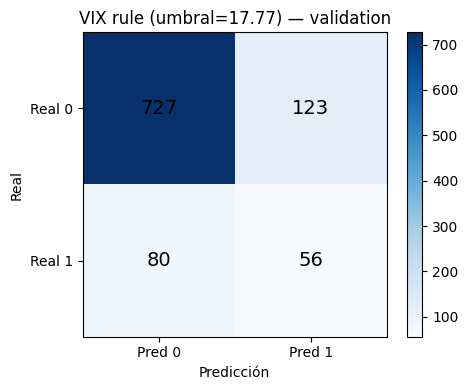

Guardado: confusion_matrix_vix_validation.png


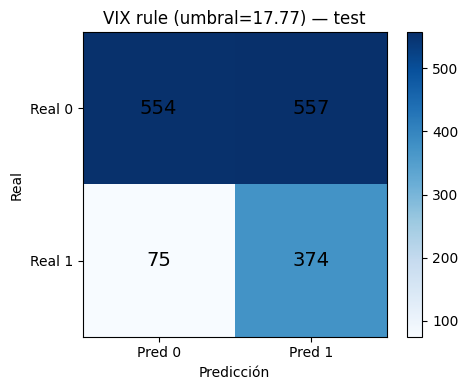

Guardado: confusion_matrix_vix_test.png


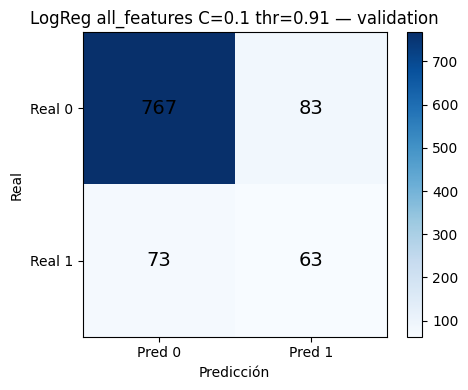

Guardado: confusion_matrix_logreg_validation.png


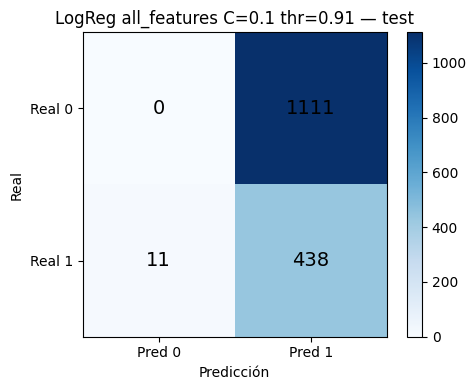

Guardado: confusion_matrix_logreg_test.png


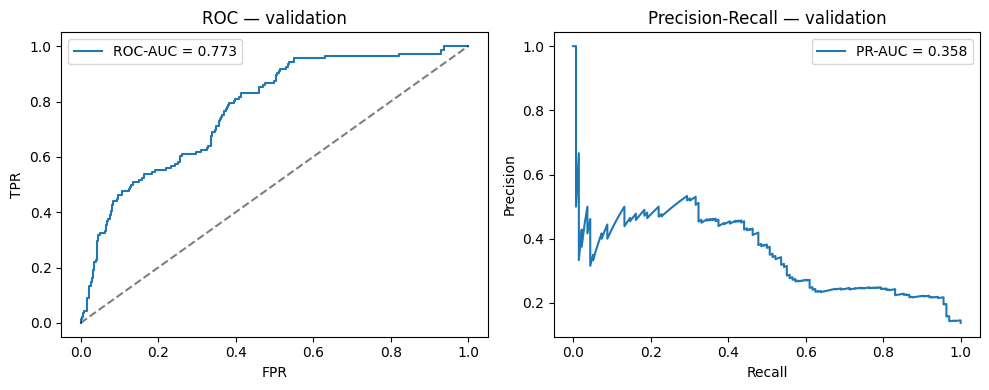

Guardado: logreg_roc_pr_validation.png


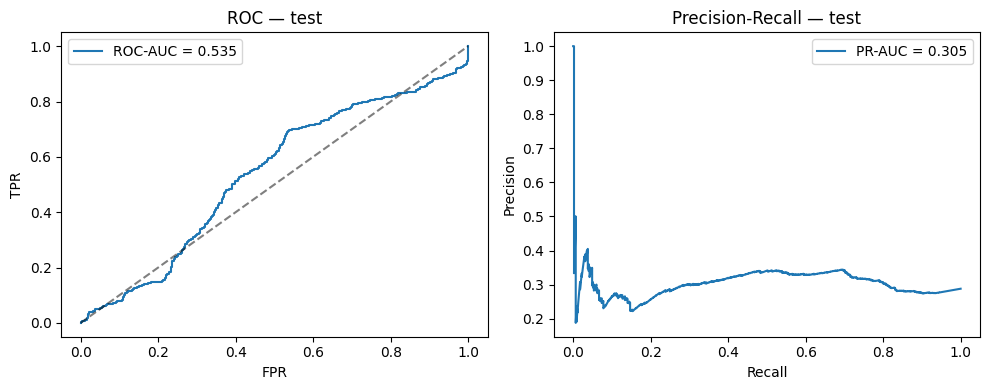

Guardado: logreg_roc_pr_test.png


In [11]:
def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Real 0", "Real 1"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    fig.savefig(save_path, dpi=120)
    plt.show()
    print("Guardado:", save_path.name)


# VIX rule
pred_vix_val = predict_vix_rule(vix_val, best_vix_threshold)
pred_vix_test = predict_vix_rule(vix_test, best_vix_threshold)

plot_confusion_matrix(
    y_val, pred_vix_val,
    f"VIX rule (umbral={best_vix_threshold:.2f}) — validation",
    REPORTS_FIGURES / "confusion_matrix_vix_validation.png",
)
plot_confusion_matrix(
    y_test, pred_vix_test,
    f"VIX rule (umbral={best_vix_threshold:.2f}) — test",
    REPORTS_FIGURES / "confusion_matrix_vix_test.png",
)

# Mejor LogReg
pred_lr_val = (proba_val >= best_logreg_threshold).astype(int)
pred_lr_test = (proba_test >= best_logreg_threshold).astype(int)

plot_confusion_matrix(
    y_val, pred_lr_val,
    f"LogReg {best_variant} C={best_C} thr={best_logreg_threshold:.2f} — validation",
    REPORTS_FIGURES / "confusion_matrix_logreg_validation.png",
)
plot_confusion_matrix(
    y_test, pred_lr_test,
    f"LogReg {best_variant} C={best_C} thr={best_logreg_threshold:.2f} — test",
    REPORTS_FIGURES / "confusion_matrix_logreg_test.png",
)


def plot_roc_pr(y_true, y_proba, split_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].set_title(f"ROC — {split_name}")
    axes[0].legend()

    axes[1].plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall — {split_name}")
    axes[1].legend()

    plt.tight_layout()
    fname = REPORTS_FIGURES / f"logreg_roc_pr_{split_name}.png"
    fig.savefig(fname, dpi=120)
    plt.show()
    print("Guardado:", fname.name)


plot_roc_pr(y_val, proba_val, "validation")
plot_roc_pr(y_test, proba_test, "test")


## 11. Conclusiones del Notebook 04

### Warnings y estabilidad numérica
- Se entrenó LogReg con **`solver="liblinear"` + `penalty="l2"`** y `np.errstate(...)` durante fit/predict.
- **Todas las probabilidades son finitas** (sin NaN/Inf); la celda 7 lo comprueba explícitamente.

### Baselines evaluados
1. **Dummy most_frequent** — referencia mínima (recall ≈ 0 en riesgo).
2. **Dummy stratified** — azar estratificado, sin aprendizaje real.
3. **Regla VIX** — riesgo cuando el VIX supera umbral calibrado en validation.
4. **Regresión logística** — búsqueda controlada en `all_features` y `reduced_no_level_features` con `C ∈ {0.01, 0.1, 1.0}`.

### Resultados concretos (validation / test)

| Enfoque | F1 validation | F1 test |
|---------|---------------|---------|
| **Regla VIX** | **0.356** | **0.542** |
| **LogReg seleccionada** (`all_features`, C=0.1, threshold=0.91) | **0.447** | **0.438** |
| **LogReg reduced** (mejor config por variante) | 0.375 | **0.553** |

- La **LogReg seleccionada por F1 en validation** (`all_features`, `C=0.1`, `threshold=0.91`) **mejora a VIX en validation** (0.447 vs 0.356), pero **no en test** (0.438 vs 0.542).
- En test, la variante **`reduced_no_level_features`** alcanza **F1 ≈ 0.553**, ligeramente **por encima de VIX** (0.542), lo que sugiere que eliminar variables de nivel/no estacionarias puede **mejorar la robustez fuera de muestra**.
- La LogReg global en test mantiene **recall muy alto (~0.98)** y **precision baja (~0.28)**: muchas falsas alarmas de riesgo.

### Métrica más informativa
Con clases desbalanceadas, **F1**, **recall** y **PR-AUC** aportan más que accuracy. **PR-AUC** es especialmente útil para comparar modelos probabilísticos.

### Implicación para el Notebook 05
El baseline ML lineal queda **definido y reproducible**, pero **no domina claramente a VIX en test**. El siguiente paso es evaluar **modelos no lineales** (Random Forest, XGBoost) para comprobar si capturan **interacciones más robustas** que la regresión logística.

---

## 12. Siguiente paso

Modelos no lineales (Random Forest, XGBoost): **`notebooks/05_tree_models.ipynb`**.  
Análisis de errores e interpretabilidad: **`notebooks/06_error_analysis_interpretability.ipynb`**.
